<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/Gaussian_Mixture_Model_on_Customers_in_Mall_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

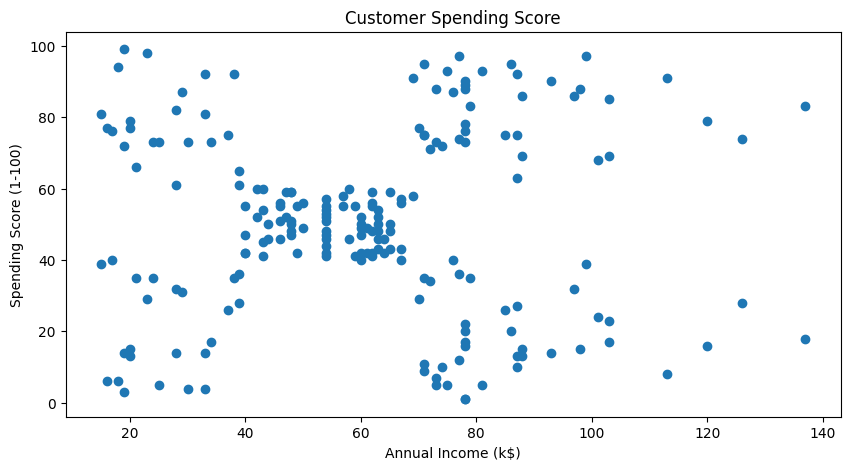

In [4]:
plt.figure(figsize=(10,5))
plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Spending Score')
plt.show()

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
bic_scores = []

for k in range(1,11):
  gmm = GaussianMixture(
      n_components=k,
      random_state=42
  )

  gmm.fit(X_scaled)
  bic_scores.append(gmm.bic(X_scaled))

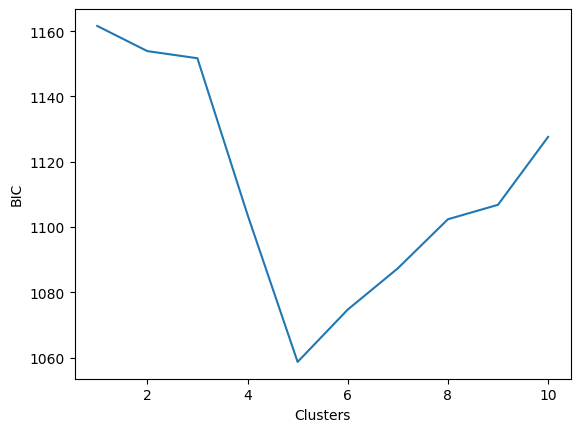

In [8]:
plt.plot(range(1,11),bic_scores)
plt.xlabel('Clusters')
plt.ylabel('BIC')
plt.show()

In [9]:
gmm = GaussianMixture(
    n_components=5,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

In [10]:
clusters = gmm.predict(X_scaled)
df['Cluster'] = clusters

In [11]:
probabilities = gmm.predict_proba(X_scaled)

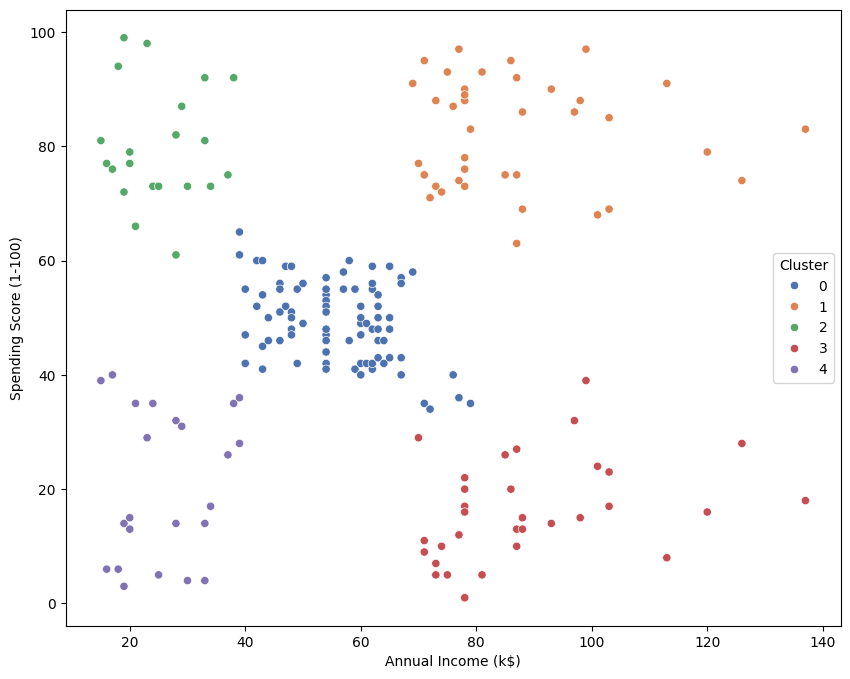

In [12]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='deep'
)

plt.show()

In [13]:
centers = scaler.inverse_transform(
    gmm.means_
)

print(centers)

[[55.71035388 49.406987  ]
 [86.2406333  82.02037497]
 [25.1174861  80.1281741 ]
 [88.8130081  16.12461835]
 [27.03115216 22.16670158]]
